# Association Rule Mining Results — Conditions Preceding High Volatility (FP-Growth)

INFS3208 Individual Project — Distributed Market Analytics

Loads the FP-Growth model already trained and saved by
`src/models/association_rules.py`. Each engineered feature is discretized
into low/mid/high tertile bins (edges fit on the train split only), and each
window becomes a "transaction" — a set of items such as
`{avg_spread_bps=high, realized_vol_book=high, target=high}`. FP-Growth then
mines frequent itemsets and rules over these transactions.

This task is descriptive/unsupervised rather than predictive, so there is no
train/test accuracy figure the way the other three tasks have one. Instead,
the top rules whose consequent is `target=high` (an upcoming high-volatility
window) are re-checked against the held-out test split below: their support
and confidence are recomputed there and compared to what FP-Growth found on
train, to confirm the rules reflect real structure rather than a train-set
artifact.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.append(str(Path("../src/pipeline").resolve()))
sys.path.append(str(Path("../src/models").resolve()))

from spark_session import get_spark
from regression import DATA_PROCESSED, load_split
from association_rules import (
    MODELS_DIR, ALL_COLS, OUTCOME_COL, MIN_SUPPORT, MIN_CONFIDENCE,
    fit_tertile_edges, add_all_items,
)
from pyspark.ml.fpm import FPGrowthModel
from pyspark.sql import functions as F

spark = get_spark()
model = FPGrowthModel.load(str(MODELS_DIR / "association_rules_best"))
print("Loaded FPGrowth model | minSupport =", MIN_SUPPORT, "| minConfidence =", MIN_CONFIDENCE)

26/09/23 00:32:50 WARN Utils: Your hostname, Anders-MacBook.local resolves to a loopback address: 127.0.0.1; using 130.102.176.144 instead (on interface en0)
26/09/23 00:32:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/23 00:32:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded FPGrowth model | minSupport = 0.05 | minConfidence = 0.3


## 1. Tertile bin edges

Recomputed here from the train split for reference — these are the exact
thresholds ("low" / "mid" / "high") each feature was discretized into
before mining.

In [2]:
train = load_split(spark, "train").cache()
val = load_split(spark, "val")
test = load_split(spark, "test").cache()

edges = {c: fit_tertile_edges(train, c) for c in ALL_COLS}
edges_table = pd.DataFrame(
    [{"feature": c, "low_below": q1, "high_at_or_above": q2} for c, (q1, q2) in edges.items()]
).set_index("feature")
edges_table

,low_below,high_at_or_above
feature,,
avg_spread_bps,3.134097,6.491511
total_ofi,-1690.000000,2057.000000
trade_volume,6704.000000,20428.000000
trade_count,45.000000,87.000000
realized_vol_book,0.001765,0.002924
target,0.002334,0.003997


## 2. Frequent itemsets

The most common item combinations across all training windows (each item is
one feature's bin, e.g. `trade_count=high`).

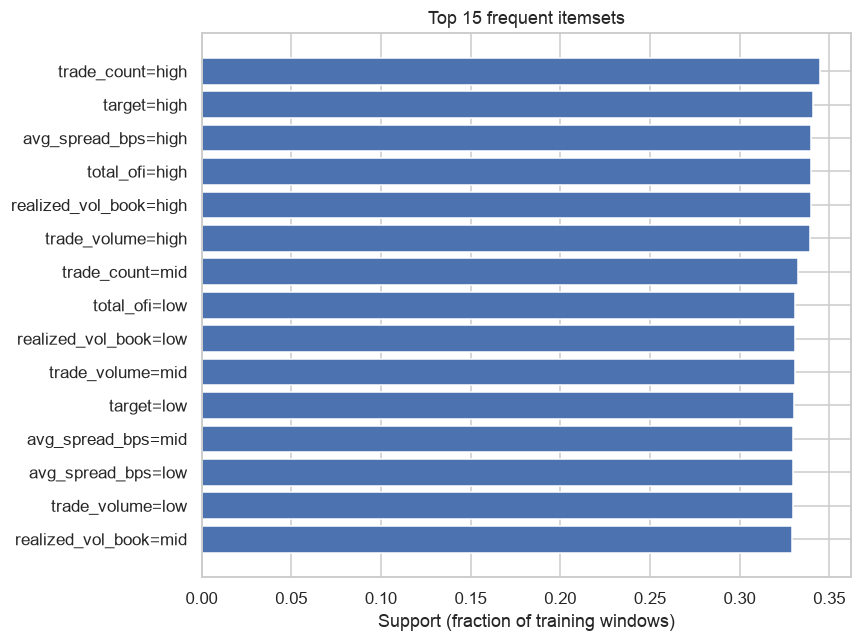

In [3]:
freq_pd = model.freqItemsets.orderBy(F.desc("freq")).limit(15).toPandas()
freq_pd["items_str"] = freq_pd["items"].apply(lambda x: ", ".join(x))
freq_pd["support"] = freq_pd["freq"] / train.count()

plt.figure(figsize=(8, 6))
plt.barh(freq_pd["items_str"][::-1], freq_pd["support"][::-1], color="#4C72B0")
plt.xlabel("Support (fraction of training windows)")
plt.title("Top 15 frequent itemsets")
plt.tight_layout()
plt.show()

## 3. Rules predicting an upcoming high-volatility window

All mined rules whose consequent is `target=high`, sorted by confidence.
**Lift** > 1 means the antecedent condition makes `target=high` more likely
than its base rate (roughly 1/3 under tertile bins) — a lift of ~2.8 means
the rule roughly triples the odds.

In [4]:
vol_rules = (
    model.associationRules
    .filter(F.array_contains(F.col("consequent"), "target=high"))
    .orderBy(F.desc("confidence"))
)
vol_rules_pd = vol_rules.limit(20).toPandas()
vol_rules_pd["antecedent"] = vol_rules_pd["antecedent"].apply(lambda x: ", ".join(x))
vol_rules_pd["consequent"] = vol_rules_pd["consequent"].apply(lambda x: ", ".join(x))
vol_rules_pd[["antecedent", "consequent", "support", "confidence", "lift"]]

,antecedent,consequent,support,confidence,lift
0,"realized_vol_book=high, avg_spread_bps=high, t...",target=high,0.053732,0.958227,2.811385
1,"avg_spread_bps=high, trade_count=high",target=high,0.054368,0.954850,2.801478
2,"trade_volume=low, realized_vol_book=high, avg_...",target=high,0.070344,0.920823,2.701645
3,"trade_count=low, trade_volume=low, realized_vo...",target=high,0.055781,0.918951,2.696152
4,"trade_count=low, trade_volume=low, realized_vo...",target=high,0.055862,0.917042,2.690550
5,"trade_volume=low, realized_vol_book=high",target=high,0.071020,0.913321,2.679633
6,"total_ofi=mid, realized_vol_book=high, avg_spr...",target=high,0.060531,0.908753,2.666230
7,"realized_vol_book=high, avg_spread_bps=high",target=high,0.190633,0.906627,2.659993
8,"total_ofi=low, realized_vol_book=high, avg_spr...",target=high,0.064746,0.906500,2.659621
9,"realized_vol_book=high, total_ofi=high, avg_sp...",target=high,0.065356,0.904792,2.654610


## 4. Confidence vs. lift across all `target=high` rules

Point size encodes support (how common the antecedent condition is). Rules
in the upper-right — high confidence *and* high lift — are both reliable and
meaningfully better than chance.

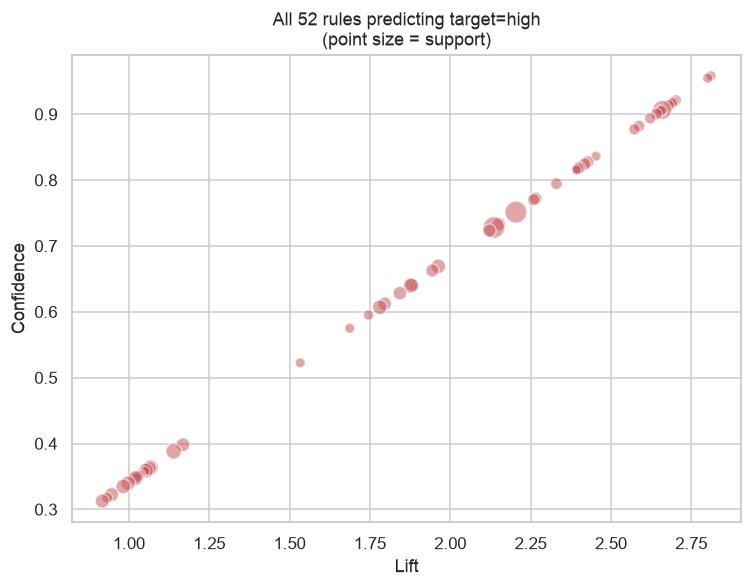

In [5]:
all_vol_rules_pd = vol_rules.toPandas()

plt.figure(figsize=(7, 5.5))
sc = plt.scatter(
    all_vol_rules_pd["lift"], all_vol_rules_pd["confidence"],
    s=all_vol_rules_pd["support"] * 800, alpha=0.5, color="#C44E52", edgecolor="white",
)
plt.xlabel("Lift")
plt.ylabel("Confidence")
plt.title(f"All {len(all_vol_rules_pd)} rules predicting target=high\n(point size = support)")
plt.tight_layout()
plt.show()

## 5. Test-set validation of the top 5 rules

FP-Growth was fit on train only. Here the top 5 rules by train confidence
are re-evaluated directly on the untouched test split: support and
confidence are recomputed from scratch by filtering test transactions,
not read from the model.

In [6]:
test_items = add_all_items(test, edges).select("items").cache()
test_n = test_items.count()

rows = []
for r in vol_rules.limit(5).collect():
    antecedent = list(r["antecedent"])
    cond = None
    for item in antecedent:
        c = F.array_contains(F.col("items"), item)
        cond = c if cond is None else (cond & c)
    support_n = test_items.filter(cond).count()
    confident_n = test_items.filter(cond & F.array_contains(F.col("items"), "target=high")).count()
    rows.append({
        "antecedent": ", ".join(antecedent),
        "train_support": r["support"],
        "train_confidence": r["confidence"],
        "train_lift": r["lift"],
        "test_support": support_n / test_n,
        "test_confidence": confident_n / support_n if support_n > 0 else float("nan"),
    })

validation_table = pd.DataFrame(rows).set_index("antecedent")
validation_table["confidence_gap"] = validation_table["test_confidence"] - validation_table["train_confidence"]
validation_table

,train_support,train_confidence,train_lift,test_support,test_confidence,confidence_gap
antecedent,,,,,,
"realized_vol_book=high, avg_spread_bps=high, trade_count=high",0.053732,0.958227,2.811385,0.047080,0.958832,0.000605
"avg_spread_bps=high, trade_count=high",0.054368,0.954850,2.801478,0.047743,0.955586,0.000736
"trade_volume=low, realized_vol_book=high, avg_spread_bps=high",0.070344,0.920823,2.701645,0.074894,0.913515,-0.007309
"trade_count=low, trade_volume=low, realized_vol_book=high, avg_spread_bps=high",0.055781,0.918951,2.696152,0.058610,0.909836,-0.009115
"trade_count=low, trade_volume=low, realized_vol_book=high",0.055862,0.917042,2.690550,0.058792,0.907580,-0.009462


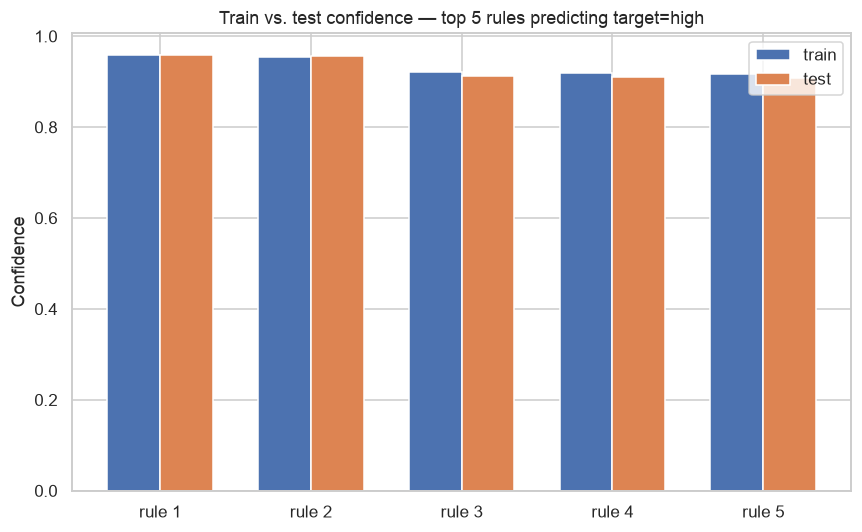

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(validation_table))
width = 0.35
ax.bar([i - width / 2 for i in x], validation_table["train_confidence"], width, label="train", color="#4C72B0")
ax.bar([i + width / 2 for i in x], validation_table["test_confidence"], width, label="test", color="#DD8452")
ax.set_xticks(list(x))
ax.set_xticklabels([f"rule {i+1}" for i in x])
ax.set_ylabel("Confidence")
ax.set_title("Train vs. test confidence — top 5 rules predicting target=high")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- The strongest rule — `{realized_vol_book=high, avg_spread_bps=high,
  trade_count=high} → {target=high}` — holds **95.8% confidence on train and
  95.9% on test**, with lift ≈ 2.8 (roughly triples the odds of an upcoming
  high-volatility window versus the ~33% base rate). The near-zero
  train/test gap across all top 5 rules is strong evidence these are real
  patterns, not artifacts of the train split.
- The same two features — `realized_vol_book` and `avg_spread_bps` — that
  dominated the regression task's feature importances (0.52 and 0.22) and
  characterized the K-Means "stressed" cluster are also the core antecedents
  of the strongest rules here. All four MLlib tasks independently converge
  on the same story: current-window realized volatility and spread are the
  clearest signals of what happens next.
- Association rule mining is unsupervised/descriptive by nature (mined
  purely from feature co-occurrence, with no accuracy metric to optimize),
  which is why the test-set re-check here — not required by the algorithm
  itself — was added deliberately to demonstrate generalization the same way
  the other three tasks do.

In [8]:
spark.stop()